In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
path = r"C:\Users\altay\Downloads\archive (8)\Student Depression Dataset.csv"

df = pd.read_csv(path)

df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [2]:
df.shape

(27901, 18)

In [3]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')

In [4]:
print("Number of rows", df.shape[0])
print("Number of columns",df.shape[1])

print("\nColumn names: ",df.columns.tolist())

print("\nMissing valuse : ",df.isnull().sum())

print("\n Dupicated Rows : ",df.duplicated().sum())


Number of rows 27901
Number of columns 18

Column names:  ['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression']

Missing valuse :  id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study

In [5]:
numeric_cols=df.select_dtypes(include=["int","float64"]).columns

categorical_cols=df.select_dtypes(include=["object"]).columns

print("numerical Columns",numeric_cols.tolist())
print("\nCategorical Columns",categorical_cols.tolist())
df[numeric_cols].describe().T

numerical Columns ['id', 'Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress', 'Depression']

Categorical Columns ['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']


,count,mean,std,min,25%,50%,75%,max
id,27901.0,70442.149421,40641.175216,2.0,35039.00,70684.00,105818.00,140699.0
Age,27901.0,25.822300,4.905687,18.0,21.00,25.00,30.00,59.0
Academic Pressure,27901.0,3.141214,1.381465,0.0,2.00,3.00,4.00,5.0
Work Pressure,27901.0,0.000430,0.043992,0.0,0.00,0.00,0.00,5.0
CGPA,27901.0,7.656104,1.470707,0.0,6.29,7.77,8.92,10.0
Study Satisfaction,27901.0,2.943837,1.361148,0.0,2.00,3.00,4.00,5.0
Job Satisfaction,27901.0,0.000681,0.044394,0.0,0.00,0.00,0.00,4.0
Work/Study Hours,27901.0,7.156984,3.707642,0.0,4.00,8.00,10.00,12.0
Financial Stress,27898.0,3.139867,1.437347,1.0,2.00,3.00,4.00,5.0
Depression,27901.0,0.585499,0.492645,0.0,0.00,1.00,1.00,1.0


In [6]:

print("Work Pressure value counts")
display(df["Work Pressure"].value_counts().sort_index())

print("\nJob Satisfaction value counts")
display(df["Job Satisfaction"].value_counts().sort_index())

Work Pressure value counts


Work Pressure
0.0    27898
2.0        1
5.0        2
Name: count, dtype: int64


Job Satisfaction value counts


Job Satisfaction
0.0    27893
1.0        2
2.0        3
3.0        1
4.0        2
Name: count, dtype: int64

<p style="font-size:20px; color:white;">
Here as u can see the feature Job Satisfaction and work pressure has mean nearly 0 , its confusing because the features has 5 classes why it is like that , the answer because most of the data are students which they don't have job and work pressure  
</p>

In [7]:
display(df["Sleep Duration"].value_counts())
display(df["Dietary Habits"].value_counts())
display(df["Profession"].value_counts())


Sleep Duration
Less than 5 hours    8310
7-8 hours            7346
5-6 hours            6183
More than 8 hours    6044
Others                 18
Name: count, dtype: int64

Dietary Habits
Unhealthy    10317
Moderate      9921
Healthy       7651
Others          12
Name: count, dtype: int64

Profession
Student                   27870
Architect                     8
Teacher                       6
Digital Marketer              3
Chef                          2
Content Writer                2
Pharmacist                    2
Doctor                        2
UX/UI Designer                1
Civil Engineer                1
Manager                       1
Educational Consultant        1
Lawyer                        1
Entrepreneur                  1
Name: count, dtype: int64

<p style="font-size:20px; color:WHITE;">
Here in the features Sleep duration and dietary habits has one class called others is different from the others classes it is big difference we will just dropping it , and the profession column has big difference it is imbalanced and already all the datasets about students so we will drop the column
</p>

In [8]:
display(df["Degree"].value_counts())

Degree
Class 12    6080
B.Ed        1867
B.Com       1506
B.Arch      1478
BCA         1433
MSc         1190
B.Tech      1152
MCA         1044
M.Tech      1022
BHM          925
BSc          888
M.Ed         821
B.Pharm      810
M.Com        734
BBA          696
MBBS         696
LLB          671
BE           613
BA           600
M.Pharm      582
MD           572
MBA          562
MA           544
PhD          522
LLM          482
MHM          191
ME           185
Others        35
Name: count, dtype: int64

<p style="font-size:20px; color:WHITE;">
here as u can see there is a lot of classes in feature degree like b.pharm ,M.Com and B.Arch so i will just merge all of them in four classes Class 12 , bachelors ,master and phd to make it easier to understand   
</p>


Cleaning

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)

path = r"C:\Users\altay\Downloads\archive (8)\Student Depression Dataset.csv"
df = pd.read_csv(path)

df_clean = df.copy()

df_clean = df_clean.drop(columns=["id"])

df_clean = df_clean.dropna(subset=["Financial Stress"])

df_clean = df_clean[df_clean["Profession"] == "Student"].copy()

df_clean = df_clean.drop(columns=["Profession"])

df_clean = df_clean[df_clean["Dietary Habits"] != "Others"].copy()
df_clean = df_clean[df_clean["Sleep Duration"] != "Others"].copy()

df_clean = df_clean.drop(
    columns=["Work Pressure", "Job Satisfaction"],
    errors="ignore"
)

city_counts = df_clean["City"].value_counts()
df_clean = df_clean[df_clean["City"].map(city_counts) >= 10].copy()

bachelors = [
    "B.Ed", "B.Com", "B.Arch", "BCA", "B.Tech", "BHM",
    "BSc", "B.Pharm", "BBA", "LLB", "BE", "BA"
]

masters = [
    "MSc", "MCA", "M.Tech", "M.Ed", "M.Com", "MBBS",
    "M.Pharm", "MBA", "MA", "LLM", "MHM", "ME", "MD"
]

def group_degree(degree):
    if degree in bachelors:
        return "Bachelors"
    elif degree in masters:
        return "Masters"
    elif degree == "PhD":
        return "PhD"
    elif "Class 12" in degree:
        return "Class 12"
    else:
        return "Other"

df_clean["Degree Level"] = df_clean["Degree"].apply(group_degree)

df_clean = df_clean[df_clean["Degree Level"] != "Other"].copy()

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

display(df_clean.head())
display(df_clean.isnull().sum())

Original shape: (27901, 18)
Cleaned shape: (27776, 15)


,Gender,Age,City,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression,Degree Level
0,Male,33.0,Visakhapatnam,5.0,8.97,2.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1,Bachelors
1,Female,24.0,Bangalore,2.0,5.90,5.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0,Bachelors
2,Male,31.0,Srinagar,3.0,7.03,5.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0,Bachelors
3,Female,28.0,Varanasi,3.0,5.59,2.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1,Bachelors
4,Female,25.0,Jaipur,4.0,8.13,3.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0,Masters


Gender                                   0
Age                                      0
City                                     0
Academic Pressure                        0
CGPA                                     0
Study Satisfaction                       0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
Degree Level                             0
dtype: int64

Encoding


In [10]:
df_encoded = df_clean.copy()

df_encoded["Gender"] = df_encoded["Gender"].map({
    "Male": 0,
    "Female": 1
})

df_encoded["Have you ever had suicidal thoughts ?"] = df_encoded["Have you ever had suicidal thoughts ?"].map({
    "No": 0,
    "Yes": 1
})

df_encoded["Family History of Mental Illness"] = df_encoded["Family History of Mental Illness"].map({
    "No": 0,
    "Yes": 1
})

df_encoded["Sleep Duration"] = df_encoded["Sleep Duration"].map({
    "Less than 5 hours": 0,
    "5-6 hours": 1,
    "7-8 hours": 2,
    "More than 8 hours": 3
})

df_encoded["Dietary Habits"] = df_encoded["Dietary Habits"].map({
    "Unhealthy": 0,
    "Moderate": 1,
    "Healthy": 2
})

df_encoded["Degree Level"] = df_encoded["Degree Level"].map({
    "Class 12": 0,
    "Bachelors": 1,
    "Masters": 2,
    "PhD": 3
})

df_encoded = df_encoded.drop(columns=[ "Degree"], errors="ignore")

display(df_encoded.head())
display(df_encoded.info())

,Gender,Age,City,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression,Degree Level
0,0,33.0,Visakhapatnam,5.0,8.97,2.0,1,2,1,3.0,1.0,0,1,1
1,1,24.0,Bangalore,2.0,5.90,5.0,1,1,0,3.0,2.0,1,0,1
2,0,31.0,Srinagar,3.0,7.03,5.0,0,2,0,9.0,1.0,1,0,1
3,1,28.0,Varanasi,3.0,5.59,2.0,2,1,1,4.0,5.0,1,1,1
4,1,25.0,Jaipur,4.0,8.13,3.0,1,1,1,1.0,1.0,0,0,2


<class 'pandas.core.frame.DataFrame'>
Index: 27776 entries, 0 to 27900
Data columns (total 14 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 27776 non-null  int64  
 1   Age                                    27776 non-null  float64
 2   City                                   27776 non-null  object 
 3   Academic Pressure                      27776 non-null  float64
 4   CGPA                                   27776 non-null  float64
 5   Study Satisfaction                     27776 non-null  float64
 6   Sleep Duration                         27776 non-null  int64  
 7   Dietary Habits                         27776 non-null  int64  
 8   Have you ever had suicidal thoughts ?  27776 non-null  int64  
 9   Work/Study Hours                       27776 non-null  float64
 10  Financial Stress                       27776 non-null  float64
 11  Family 

None

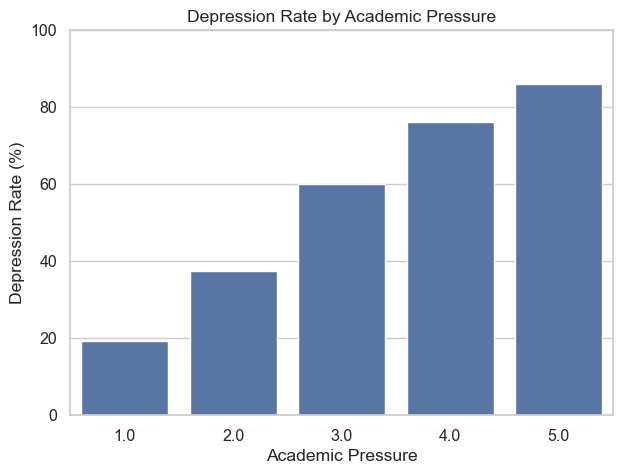

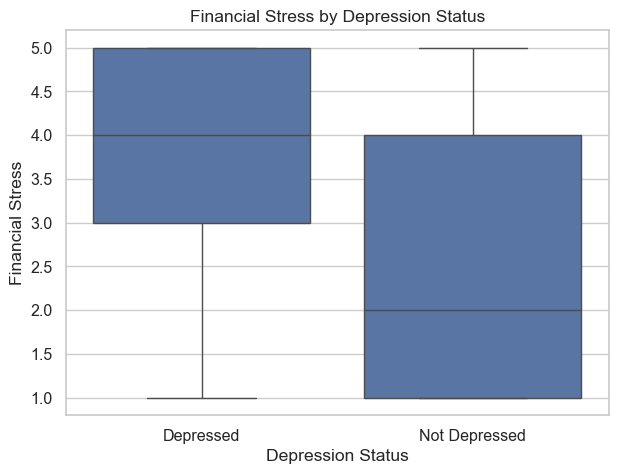

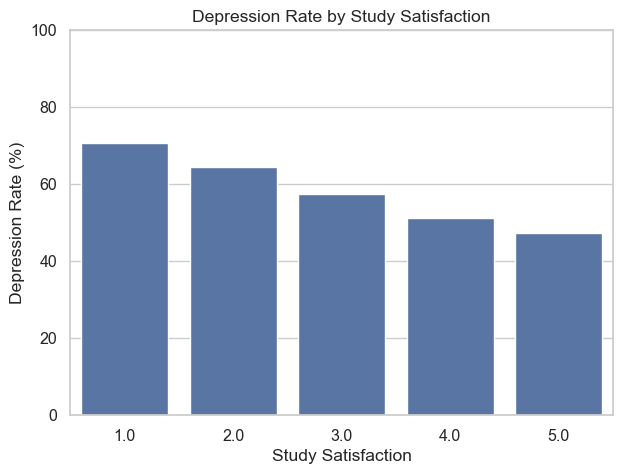

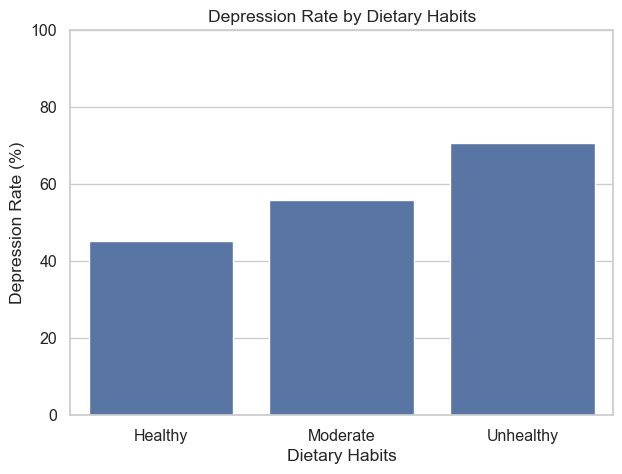

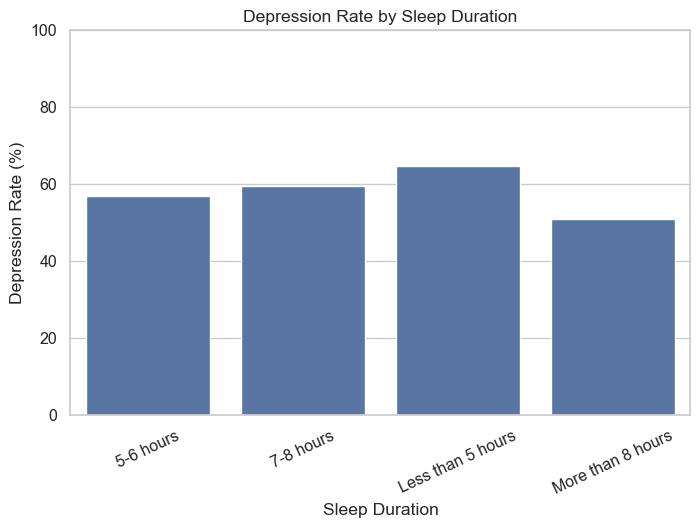

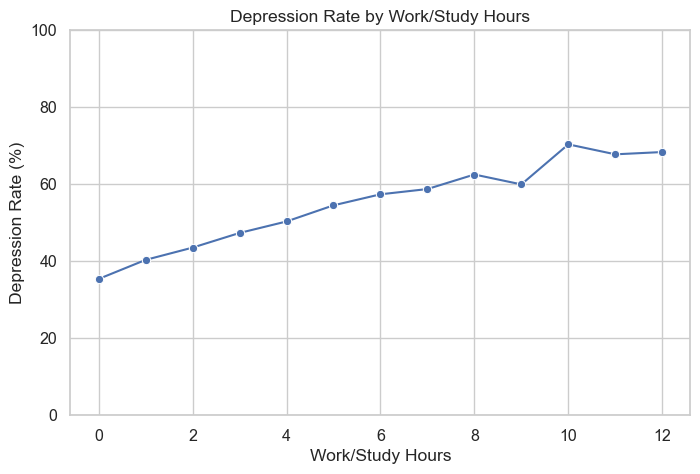

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df_clean.copy()

df_plot["Depression Label"] = df_plot["Depression"].map({
    0: "Not Depressed",
    1: "Depressed"
})


academic_data = df_plot[df_plot["Academic Pressure"] != 0]

academic_rate = academic_data.groupby("Academic Pressure")["Depression"].mean() * 100
academic_rate = academic_rate.reset_index()
academic_rate.columns = ["Academic Pressure", "Depression Rate"]

plt.figure(figsize=(7, 5))
sns.barplot(data=academic_rate, x="Academic Pressure", y="Depression Rate")
plt.title("Depression Rate by Academic Pressure")
plt.xlabel("Academic Pressure")
plt.ylabel("Depression Rate (%)")
plt.ylim(0, 100)
plt.show()


plt.figure(figsize=(7, 5))
sns.boxplot(data=df_plot, x="Depression Label", y="Financial Stress")
plt.title("Financial Stress by Depression Status")
plt.xlabel("Depression Status")
plt.ylabel("Financial Stress")
plt.show()


study_data = df_plot[df_plot["Study Satisfaction"] != 0]

study_rate = study_data.groupby("Study Satisfaction")["Depression"].mean() * 100
study_rate = study_rate.reset_index()
study_rate.columns = ["Study Satisfaction", "Depression Rate"]

plt.figure(figsize=(7, 5))
sns.barplot(data=study_rate, x="Study Satisfaction", y="Depression Rate")
plt.title("Depression Rate by Study Satisfaction")
plt.xlabel("Study Satisfaction")
plt.ylabel("Depression Rate (%)")
plt.ylim(0, 100)
plt.show()


diet_rate = df_plot.groupby("Dietary Habits")["Depression"].mean() * 100
diet_rate = diet_rate.reset_index()
diet_rate.columns = ["Dietary Habits", "Depression Rate"]

plt.figure(figsize=(7, 5))
sns.barplot(data=diet_rate, x="Dietary Habits", y="Depression Rate")
plt.title("Depression Rate by Dietary Habits")
plt.xlabel("Dietary Habits")
plt.ylabel("Depression Rate (%)")
plt.ylim(0, 100)
plt.show()


sleep_rate = df_plot.groupby("Sleep Duration")["Depression"].mean() * 100
sleep_rate = sleep_rate.reset_index()
sleep_rate.columns = ["Sleep Duration", "Depression Rate"]

plt.figure(figsize=(8, 5))
sns.barplot(data=sleep_rate, x="Sleep Duration", y="Depression Rate")
plt.title("Depression Rate by Sleep Duration")
plt.xlabel("Sleep Duration")
plt.ylabel("Depression Rate (%)")
plt.ylim(0, 100)
plt.xticks(rotation=25)
plt.show()


work_rate = df_plot.groupby("Work/Study Hours")["Depression"].mean() * 100
work_rate = work_rate.reset_index()
work_rate.columns = ["Work/Study Hours", "Depression Rate"]

plt.figure(figsize=(8, 5))
sns.lineplot(data=work_rate, x="Work/Study Hours", y="Depression Rate", marker="o")
plt.title("Depression Rate by Work/Study Hours")
plt.xlabel("Work/Study Hours")
plt.ylabel("Depression Rate (%)")
plt.ylim(0, 100)
plt.show()

"""
# Key Factors Associated with Student Depression

## 1. Academic Pressure
Academic pressure is strongly related to depression. When academic pressure is low, the depression rate is around **19.4%**, while when academic pressure is high, the depression rate is around **86.1%**. This shows a strong relationship between academic pressure and depression.

## 2. Financial Stress
Financial stress is higher among depressed students. The boxplot shows that students classified as depressed have higher financial stress levels than students who are not depressed.

## 3. Study Satisfaction
Students with low study satisfaction have higher depression rates. When study satisfaction is low, the depression rate is around **70.7%**, while students with high study satisfaction have a depression rate around **47.2%**.

## 4. Lifestyle Habits
Poor lifestyle habits are associated with depression. Students with healthy dietary habits have a depression rate around **45.3%**, while students with unhealthy habits have a depression rate around **70.7%**. Also, students sleeping less than 5 hours show more depression cases.

## 5. Work/Study Hours
Students who spend more hours studying or working per day tend to have higher levels of depression. This may be because long daily hours can increase stress and leave less time for rest.
"""